In [1]:
%matplotlib inline

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,5)
print(f"Tensorflow : {tf.__version__}")
print(f"GPU Dispo : {len(tf.config.list_physical_devices('GPU'))> 0}")


Tensorflow : 2.21.0
GPU Dispo : False


In [2]:
# Charger MNIST depuis keras

(X_train,y_train),(X_test,y_test) = tf.keras.datasets.mnist.load_data()

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test.shape}")
print()
print(f"Classes       : {np.unique(y_train)}")
print(f"Pixels min    : {X_train.min()}")
print(f"Pixels max    : {X_train.max()}")
print()

# Distribution des classes
unique, counts = np.unique(y_train,return_counts=True)
print("Distribution des classes (train)")
for c,n in zip (unique,counts):
    print(f"Chiffre {c} : {n} exemples {n/len(y_train)*100:.1f}%")



X_train shape : (60000, 28, 28)
y_train shape : (60000,)
X_test shape  : (10000, 28, 28)
y_test shape  : (10000,)

Classes       : [0 1 2 3 4 5 6 7 8 9]
Pixels min    : 0
Pixels max    : 255

Distribution des classes (train)
Chiffre 0 : 5923 exemples 9.9%
Chiffre 1 : 6742 exemples 11.2%
Chiffre 2 : 5958 exemples 9.9%
Chiffre 3 : 6131 exemples 10.2%
Chiffre 4 : 5842 exemples 9.7%
Chiffre 5 : 5421 exemples 9.0%
Chiffre 6 : 5918 exemples 9.9%
Chiffre 7 : 6265 exemples 10.4%
Chiffre 8 : 5851 exemples 9.8%
Chiffre 9 : 5949 exemples 9.9%


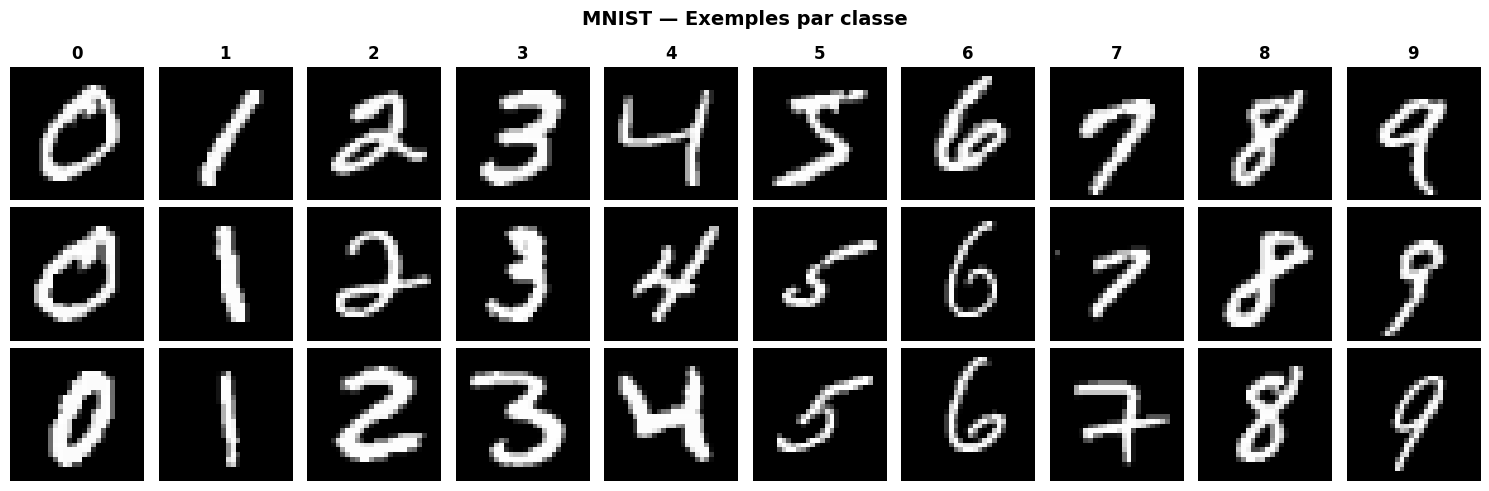


Observations :
  -> Images 28x28 pixels en niveaux de gris
  -> Chiffres centres sur fond noir
  -> Variations d'ecriture importantes entre individus
  -> Dataset equilibre (~6000 exemples par classe)


In [3]:
fig, axes = plt.subplots(3,10,figsize=(15,5))
fig.suptitle("MNIST — Exemples par classe",fontsize=14,fontweight='bold')

for digit in range(10):
    #prendre 3 exemples de chaque chiffre
    idx = np.where(y_train == digit)[0][:3]
    for row,i in enumerate(idx):
        ax = axes[row,digit]
        ax.imshow(X_train[i],cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObservations :")
print("  -> Images 28x28 pixels en niveaux de gris")
print("  -> Chiffres centres sur fond noir")
print("  -> Variations d'ecriture importantes entre individus")
print("  -> Dataset equilibre (~6000 exemples par classe)")

In [4]:
# Normalisation

# Pixels : 0-255 -> 0.0-1.0
# Diviser par 255 = regle standard pour les images

X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Flatten 
# MLP ne comprend pas les images 2D
# il faut aplatir : 28x28 -> 784

X_train_flat = X_train_norm.reshape(-1,784)
X_test_flat = X_test_norm.reshape(-1,784)

# One-hot-encoding
#  y = [3, 7, 2, ...] -> [[0,0,0,1,0,0,0,0,0,0], ...]
# Necessaire pour categorical_crossentropy
y_train_ohe = tf.keras.utils.to_categorical(y_train,10)
y_test_ohe = tf.keras.utils.to_categorical(y_test,10)

print("APRES PREPROCESSING")
print(f"X_train : {X_train_flat.shape} (60000 images, 784 pixels chacune)")
print(f"X_test : {X_test_flat.shape}")
print(f"y_train : {y_train_ohe.shape}")
print()
print(f"  Pixel min : {X_train_flat.min():.1f}")
print(f"  Pixel max : {X_train_flat.max():.1f}")
print()
print("Exemple one-hot encoding :")
print(f"  y_train[0] = {y_train[0]}")
print(f"  one-hot    = {y_train_ohe[0].astype(int)}")
print(f"  -> Position {y_train[0]} = 1, reste = 0")

APRES PREPROCESSING
X_train : (60000, 784) (60000 images, 784 pixels chacune)
X_test : (10000, 784)
y_train : (60000, 10)

  Pixel min : 0.0
  Pixel max : 1.0

Exemple one-hot encoding :
  y_train[0] = 5
  one-hot    = [0 0 0 0 0 1 0 0 0 0]
  -> Position 5 = 1, reste = 0


In [5]:
###################### Architecture MLP ##########################

# Input : 784 pixels (image aplatie)
# 
# Dense (512) + BatchNorm + ReLu + DropOut(0.3)
#
# Dense (256) + BatchNorm + ReLu + DropOut(0.3)
#
# Dense (128) + BatchNorm + ReLu + DropOut(0.3)
#
# Dense(10, Softmax) <- 1 neurone par chiffre 0-9


model_mlp = Sequential([
    #Couche 1
    Dense(512,input_shape=(784,)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    #Couche 2
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    #Couche 3
    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    Dropout(0.3),

    # Sortie : 10 classes (chiffres 0-9)
    Dense(10, activation='softmax')
    
], name="MLP_MNIST")


# Compiler
model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Afficher l'architecture
model_mlp.summary()

# Compter les parametres
total_params = model_mlp.count_params()
print(f"\nTotal parametres : {total_params:,}")
print(f"  Couche 1 : 784 x 512 + 512 = {784*512+512:,} poids")
print(f"  Couche 2 : 512 x 256 + 256 = {512*256+256:,} poids")
print(f"  Couche 3 : 256 x 128 + 128 = {256*128+128:,} poids")
print(f"  Sortie   : 128 x 10  + 10  = {128*10+10:,} poids")

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)


Total parametres : 571,018
  Couche 1 : 784 x 512 + 512 = 401,920 poids
  Couche 2 : 512 x 256 + 256 = 131,328 poids
  Couche 3 : 256 x 128 + 128 = 32,896 poids
  Sortie   : 128 x 10  + 10  = 1,290 poids


In [6]:
# CallBacks

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss',patience=5, min_lr=1e-7, factor=0.5, verbose=1)
]

# Training model
print("Debut de l'entrainement MLP...")
print("="*50)

history = model_mlp.fit(
    X_train_flat, y_train_ohe,
    validation_split=0.1,    # 10% du train = validation
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

print("\n Entrainement termine !")
print(f"   Epochs executes      : {len(history.history['loss'])}")
print(f"   Meilleure val_loss   : {min(history.history['val_loss']):.4f}")
print(f"   Meilleure val_acc    : {max(history.history['val_accuracy']):.4f}")

Debut de l'entrainement MLP...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8938 - loss: 0.3598 - val_accuracy: 0.9682 - val_loss: 0.1007 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9513 - loss: 0.1631 - val_accuracy: 0.9765 - val_loss: 0.0758 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9611 - loss: 0.1253 - val_accuracy: 0.9768 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9689 - loss: 0.1005 - val_accuracy: 0.9805 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9729 - loss: 0.0874 - val_accuracy: 0.9790 - val_loss: 0.0668 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9761 - loss: 0.0783 - val_accuracy: 0.9825 - val_loss: 0.0606 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/

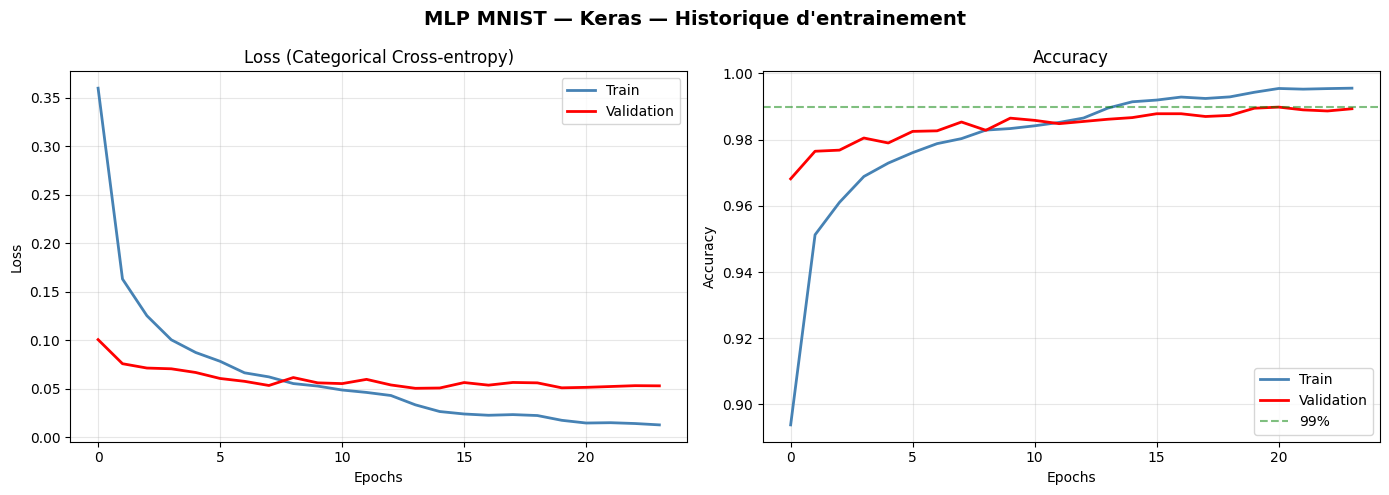

Graphique sauvegarde : assets/mlp_training_curves.png


In [10]:
# Courbe d'entrainement

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("MLP MNIST — Keras — Historique d'entrainement",
             fontsize=14, fontweight='bold')

#Loss
axes[0].plot(history.history['loss'],label='Train',color='steelblue',lw=2)
axes[0].plot(history.history['val_loss'],label='Validation',color='red',lw=2)
axes[0].set_title("Loss (Categorical Cross-entropy)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True,alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train', color='steelblue', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', color='red', lw=2)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].axhline(y=0.99, color='green', linestyle='--', alpha=0.5, label='99%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde : assets/mlp_training_curves.png")

In [11]:
# Evaluation finale sur le TEST SET

test_loss, test_acc = model_mlp.evaluate(X_test_flat, y_test_ohe, verbose=1)
print(f"test Loss : {test_loss:.4f}")
print(f"test_acc : {test_acc:.4f} ({test_acc*100:.2f}%)")
print()

# Prediction
y_pred_proba = model_mlp.predict(X_test_flat,verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)

print("="*50)
print("RAPPORT DE CLASSIFICATION")
print("="*50)
print(classification_report(
    y_test, y_pred,
    target_names=[str(i) for i in range(10)],
    digits=4
))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0498
test Loss : 0.0498
test_acc : 0.9852 (98.52%)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

           0     0.9848    0.9918    0.9883       980
           1     0.9869    0.9974    0.9921      1135
           2     0.9874    0.9835    0.9854      1032
           3     0.9775    0.9881    0.9828      1010
           4     0.9828    0.9868    0.9848       982
           5     0.9920    0.9787    0.9853       892
           6     0.9875    0.9875    0.9875       958
           7     0.9853    0.9747    0.9800      1028
           8     0.9927    0.9836    0.9881       974
           9     0.9763    0.9782    0.9772      1009

    accuracy                         0.9852     10000
   macro avg     0.9853    0.9850    0.9851     10000
weighted avg     0.9852    0.9852    0.9852     10000



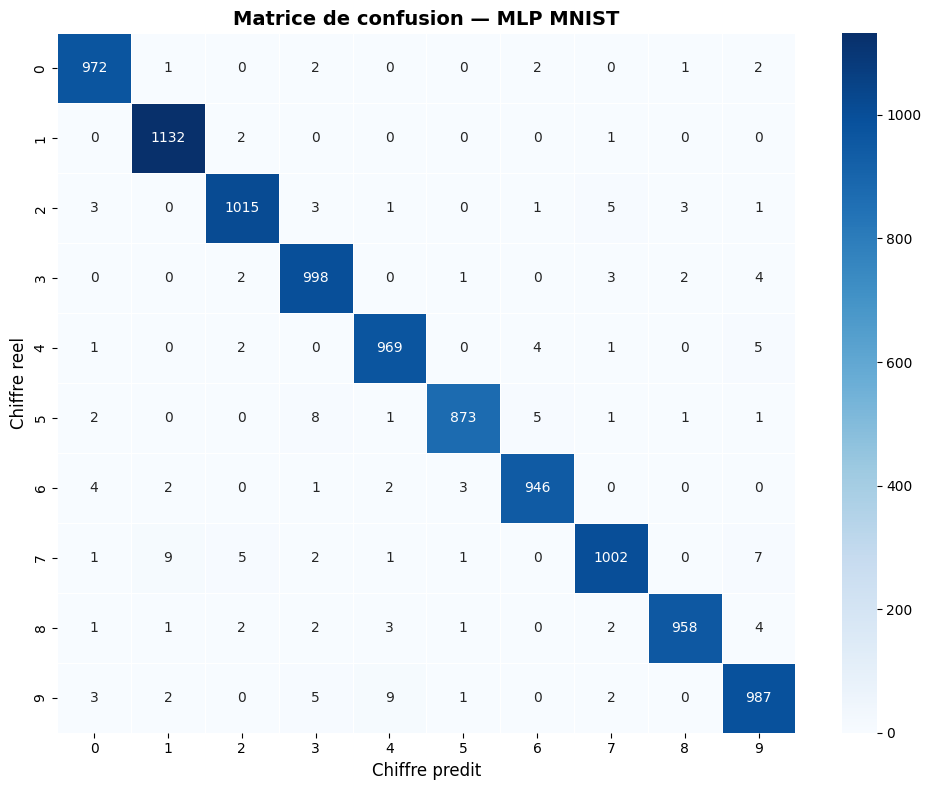


Confusions les plus frequentes :


In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, ax=ax)
ax.set_title("Matrice de confusion — MLP MNIST",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Chiffre predit", fontsize=12)
ax.set_ylabel("Chiffre reel", fontsize=12)
plt.tight_layout()
plt.savefig('../assets/confusion_matrix_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

# Trouver les confusions les plus frequentes
print("\nConfusions les plus frequentes :")
for i in range(10):
    for j in range(10):
        if i != j and cm[i,j] > 20:
            print(f"  Reel={i} predit={j} : {cm[i,j]} fois")

Nombre d'erreurs : 148 / 10000
Taux d'erreur    : 1.48%



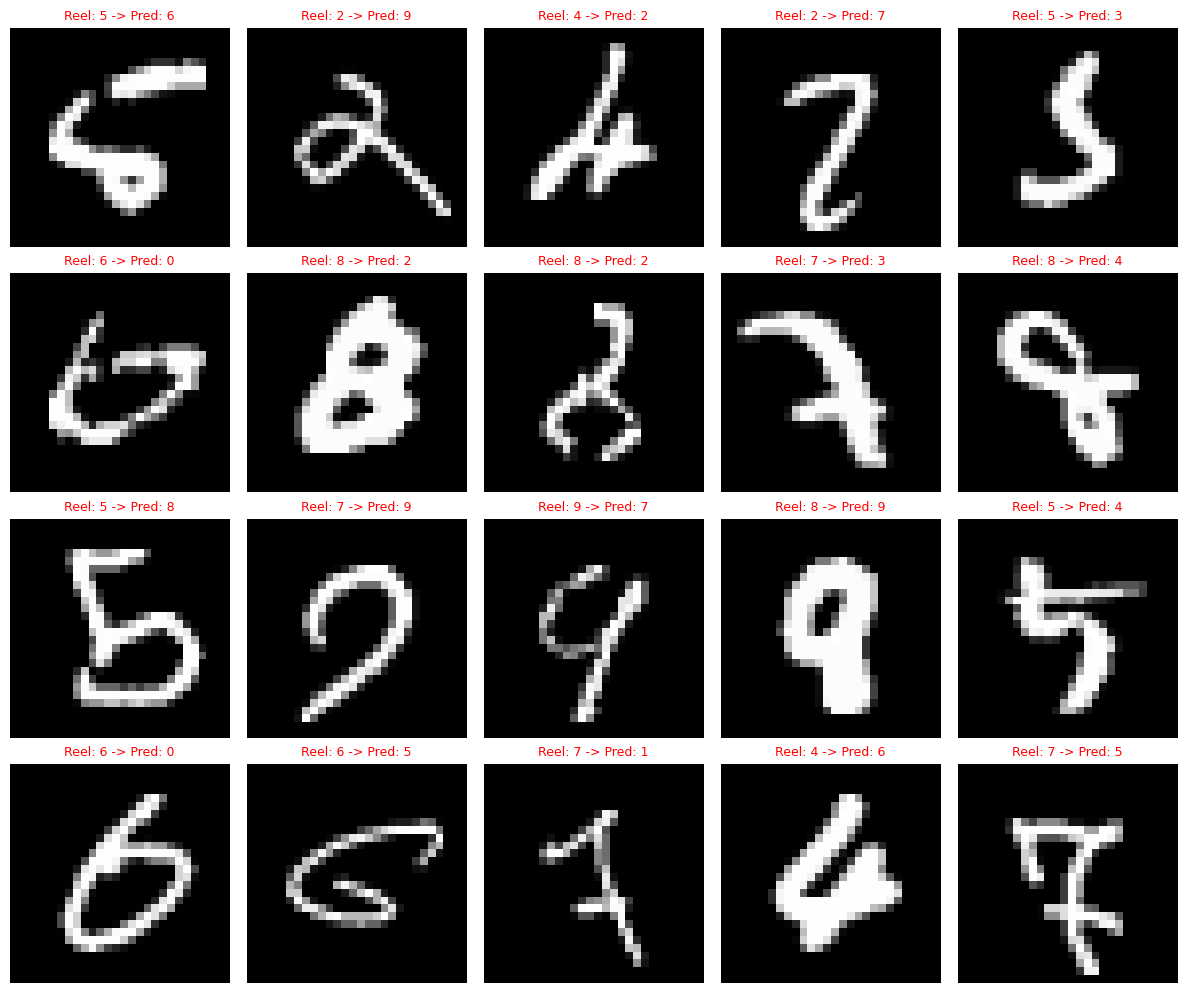

In [17]:
# Visualiser les erreurs

# Images mal classées

erreurs_idx = np.where(y_pred != y_test)[0]
n_erreurs = len(erreurs_idx)

print(f"Nombre d'erreurs : {n_erreurs} / {len(y_test)}")
print(f"Taux d'erreur    : {n_erreurs/len(y_test)*100:.2f}%")
print()

# Afficher les 20 premieres erreurs
fig, axes = plt.subplots(4,5,figsize=(12,10))

for i,ax in enumerate(axes.flatten()):
    if i < len(erreurs_idx):
        idx = erreurs_idx[i]
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f"Reel: {y_test[idx]} -> Pred: {y_pred[idx]}",fontsize=9, color='red')
    ax.axis('off')
        
plt.tight_layout()
plt.savefig('../assets/mlp_errors.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import os
os.makedirs('../models', exist_ok=True)


# Sauvegarder le modele Keras
model_mlp.save('../models/mlp_keras_mnist.keras')
print("Modele sauvegarde : models/mlp_keras_mnist.keras")
print()

print(f"  Architecture  : 784 → 512 → 256 → 128 → 10")
print(f"  Parametres    : {model_mlp.count_params():,}")
print(f"  Epochs        : {len(history.history['loss'])}")
print(f"  Val Accuracy  : {max(history.history['val_accuracy']):.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Loss     : {test_loss:.4f}")
print()
print("PROCHAINE ETAPE : MLP PyTorch ")

Modele sauvegarde : models/mlp_keras_mnist.keras

  Architecture  : 784 → 512 → 256 → 128 → 10
  Parametres    : 571,018
  Epochs        : 24
  Val Accuracy  : 0.9898
  Test Accuracy : 0.9852  (98.52%)
  Test Loss     : 0.0498

PROCHAINE ETAPE : MLP PyTorch 
